<a href="https://colab.research.google.com/github/pankajkumar8709/Machine-Learning-projects/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
import numpy as np
import pandas as pd


In [7]:
path=kagglehub.dataset_download("muhamedumarjamil/house-price-prediction-dataset")

100%|██████████| 292k/292k [00:00<00:00, 444kB/s]

Extracting files...


In [8]:
path

'/root/.cache/kagglehub/datasets/muhamedumarjamil/house-price-prediction-dataset/versions/1'

In [9]:
import os
os.listdir(path)

['house_prices_dataset.csv']

In [10]:
df=pd.read_csv(path+"/house_prices_dataset.csv")
df.sample(8)

,square_feet,num_rooms,age,distance_to_city(km),price
6745,1538.905547,2,74,11.943284,149721.103436
5703,1698.070534,2,39,16.192991,158837.488654
6370,1870.530602,7,23,27.194474,228463.058991
9034,1985.324149,4,31,12.146160,307856.640493
5326,1741.121276,7,15,26.642010,278411.437760
7653,2241.395062,2,22,10.550800,293409.928769
7783,3303.429582,4,17,8.405137,504153.483670
1999,1627.548678,6,51,21.839395,241403.630923


In [11]:
import matplotlib.pyplot  as plt
import seaborn as sns

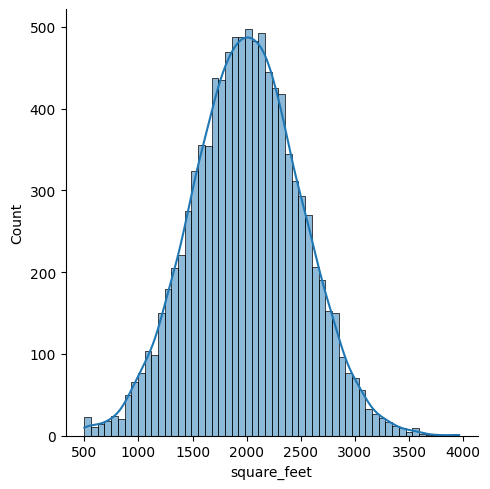

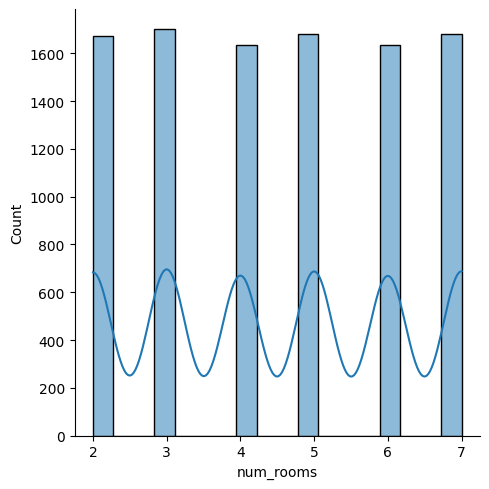

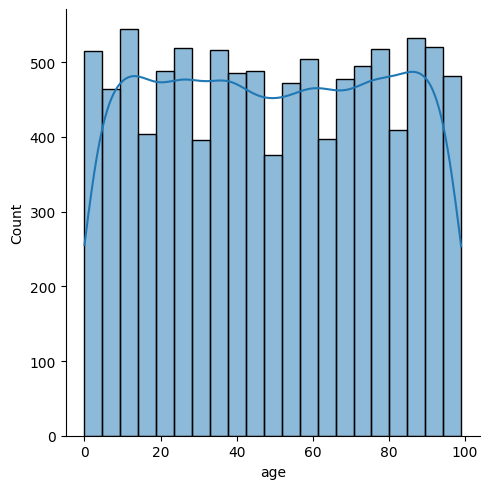

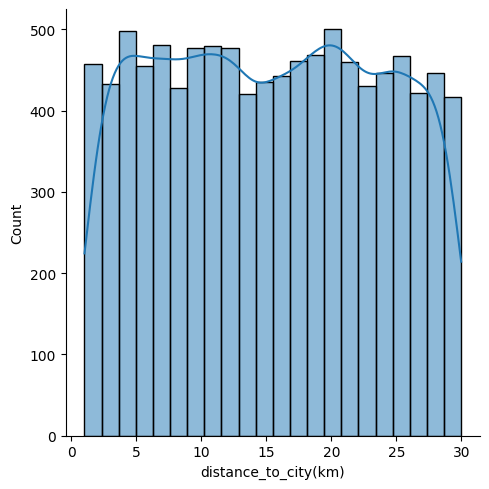

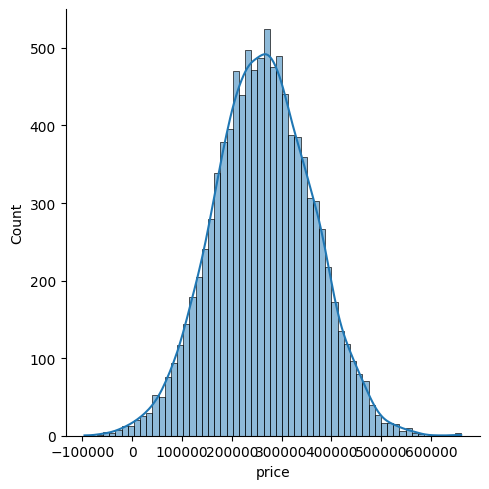

In [18]:
for i in df.columns:
  sns.displot(df[i], kde=True)


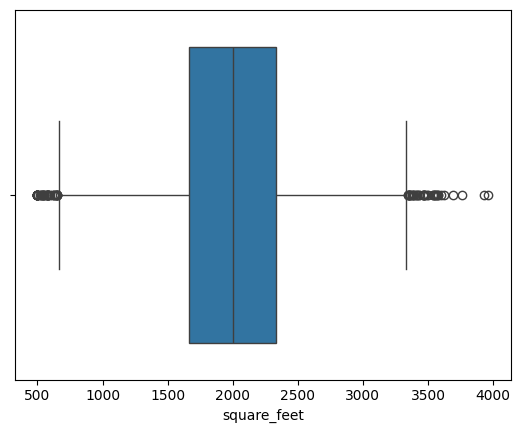

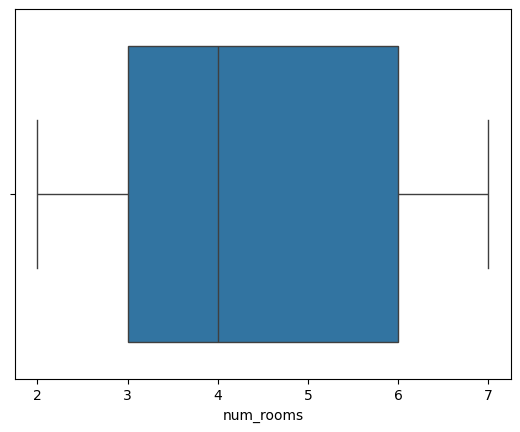

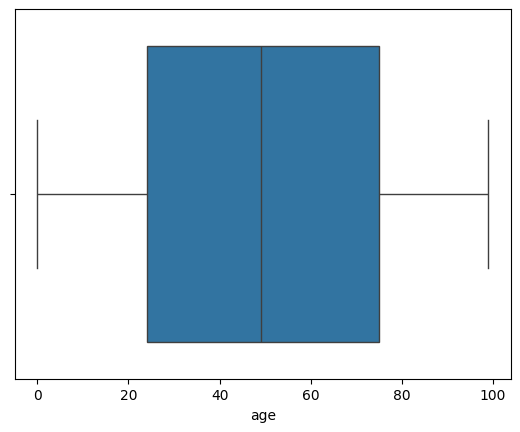

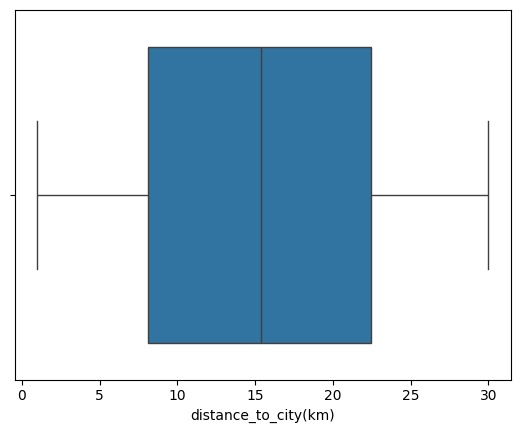

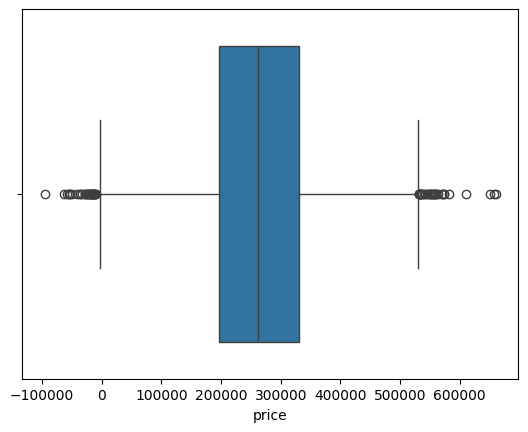

In [19]:
numerical_columns = df.select_dtypes(include=[np.number]).columns
for col in numerical_columns:
    sns.boxplot(x=df[col])
    plt.show()

<Axes: >

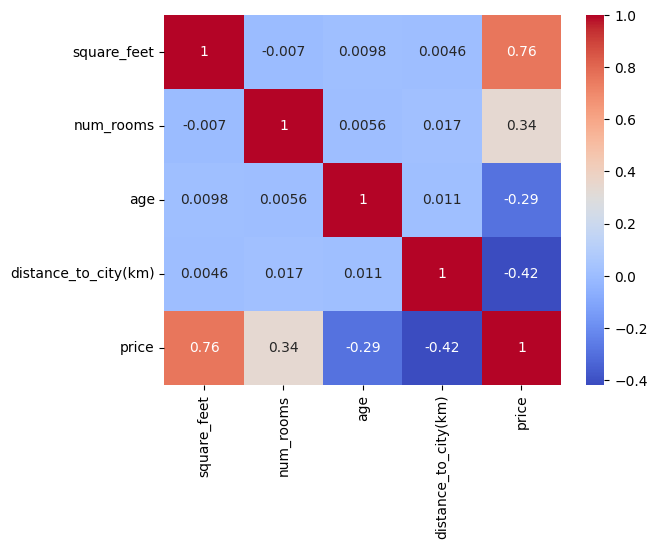

In [20]:
corr=df.select_dtypes(include='number').corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm')

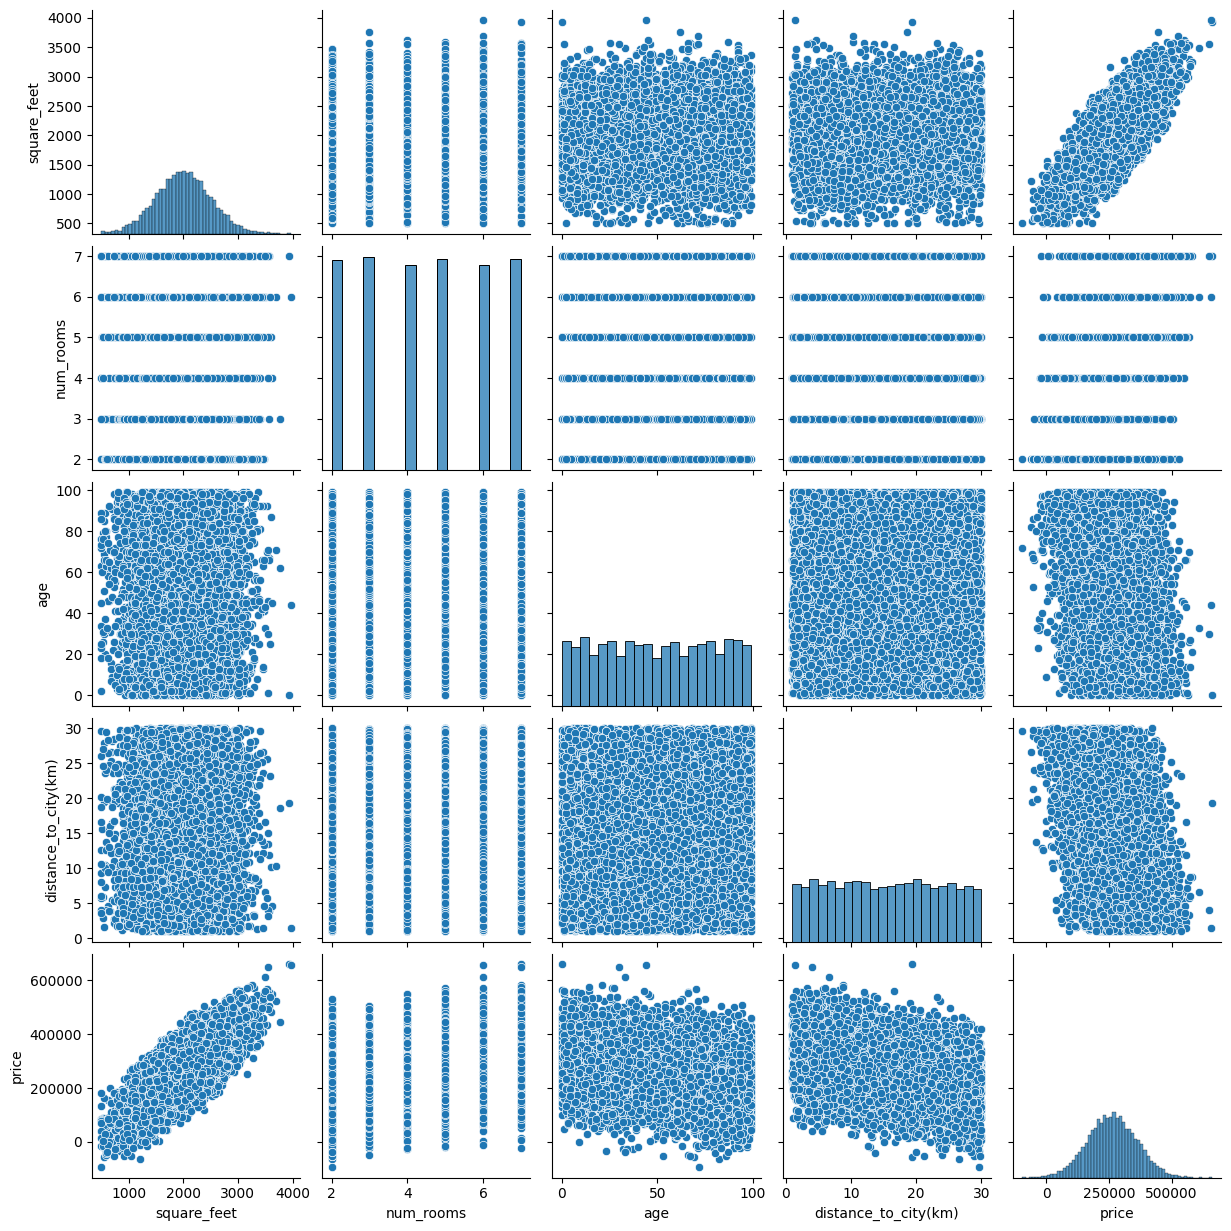

In [21]:
sns.pairplot(df[numerical_columns])

In [27]:
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,StandardScaler
from sklearn.model_selection import train_test_split


In [25]:
df.shape


(10000, 5)

In [24]:
df.isnull().sum()

,0
square_feet,0
num_rooms,0
age,0
distance_to_city(km),0
price,0


In [28]:
x_train,x_test,y_train,y_test=train_test_split(df.drop(columns=["price"]),df["price"],test_size=0.2,random_state=42)

In [29]:
x_train

,square_feet,num_rooms,age,distance_to_city(km)
9254,2109.535781,5,10,18.137401
1561,1626.394160,7,69,28.345550
1670,1880.533950,7,2,15.766694
6087,1226.099222,3,96,20.975528
6669,2351.329999,4,36,10.028462
...,...,...,...,...
5734,1712.958711,3,53,25.801195
5191,1979.353656,7,8,25.386775
5390,1650.292730,4,54,11.263292
860,2101.461510,2,35,3.259887
